# Revenue Forecasting Model

Time Series forecasting of daily aggregated revenue using Facebook Prophet on the Online Retail Dataset.

In [4]:
import os
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from datetime import timedelta

clv_data_path = 'data/online_retail.csv'

if os.path.exists(clv_data_path):
    df = pd.read_csv(clv_data_path, encoding='ISO-8859-1')
    df = df[df['Quantity'] > 0]
    df = df[df['UnitPrice'] > 0]
    df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    
    # Aggregate to daily revenue
    daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
    daily_revenue.columns = ['ds', 'y']  
    daily_revenue = daily_revenue.sort_values('ds')
    
    # Fill missing dates to make it a continuous time series
    idx = pd.date_range(daily_revenue['ds'].min(), daily_revenue['ds'].max())
    daily_revenue.set_index('ds', inplace=True)
    daily_revenue.index = pd.DatetimeIndex(daily_revenue.index)
    daily_revenue = daily_revenue.reindex(idx, method='pad').reset_index()
    daily_revenue.rename(columns={'index': 'ds'}, inplace=True)
    
    print(f'Prepared {len(daily_revenue)} continuous daily revenue records.')
else:
    print('Dataset not found. Run CLV dataset code block first to download it.')

Prepared 374 continuous daily revenue records.


## Train Forecasting Model (Prophet)

In [5]:
# Initialize and train Prophet Model
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
# Adding US holidays (feel free to change to UK since dataset is from UK e.g. 'UK')
model.add_country_holidays(country_name='US')

model.fit(daily_revenue)

# Evaluate Historical Performance
hist_predictions = model.predict(daily_revenue[['ds']])

mae = mean_absolute_error(daily_revenue['y'], hist_predictions['yhat'])
rmse = np.sqrt(mean_squared_error(daily_revenue['y'], hist_predictions['yhat']))
mape = np.mean(np.abs((daily_revenue['y'] - hist_predictions['yhat']) / daily_revenue['y'])) * 100

print(f'Mean Absolute Error (MAE): ')
print(f'Root Mean Squared Error (RMSE): ')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

01:37:14 - cmdstanpy - INFO - Chain [1] start processing


01:37:14 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 
Root Mean Squared Error (RMSE): 
Mean Absolute Percentage Error (MAPE): 34.80%


## Forecasting the Future

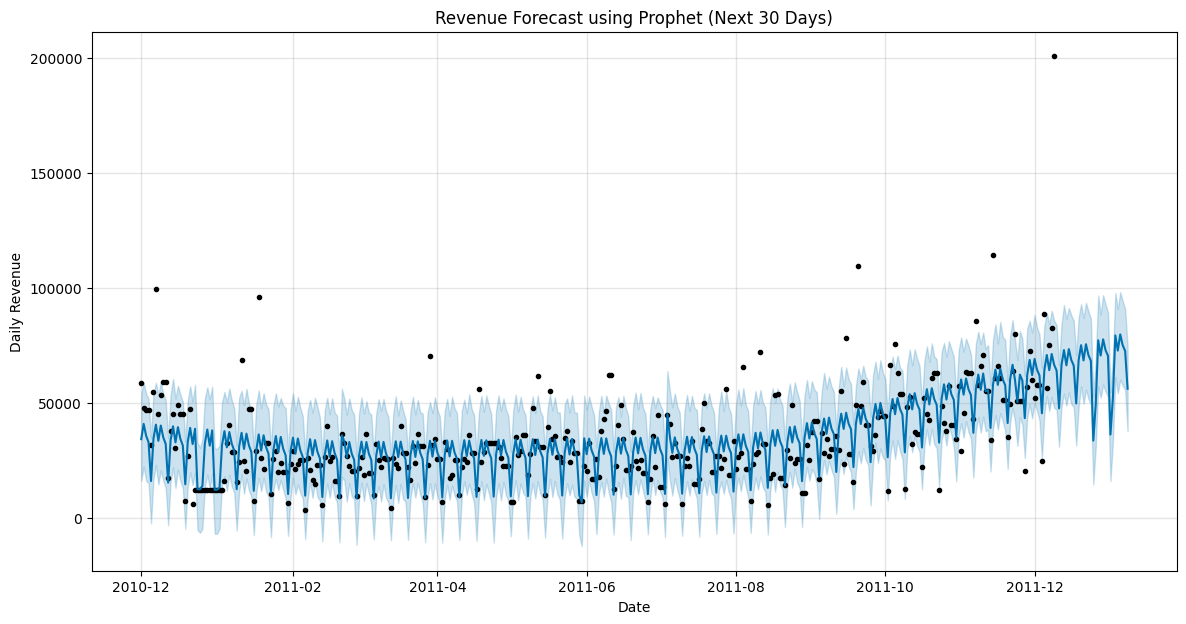

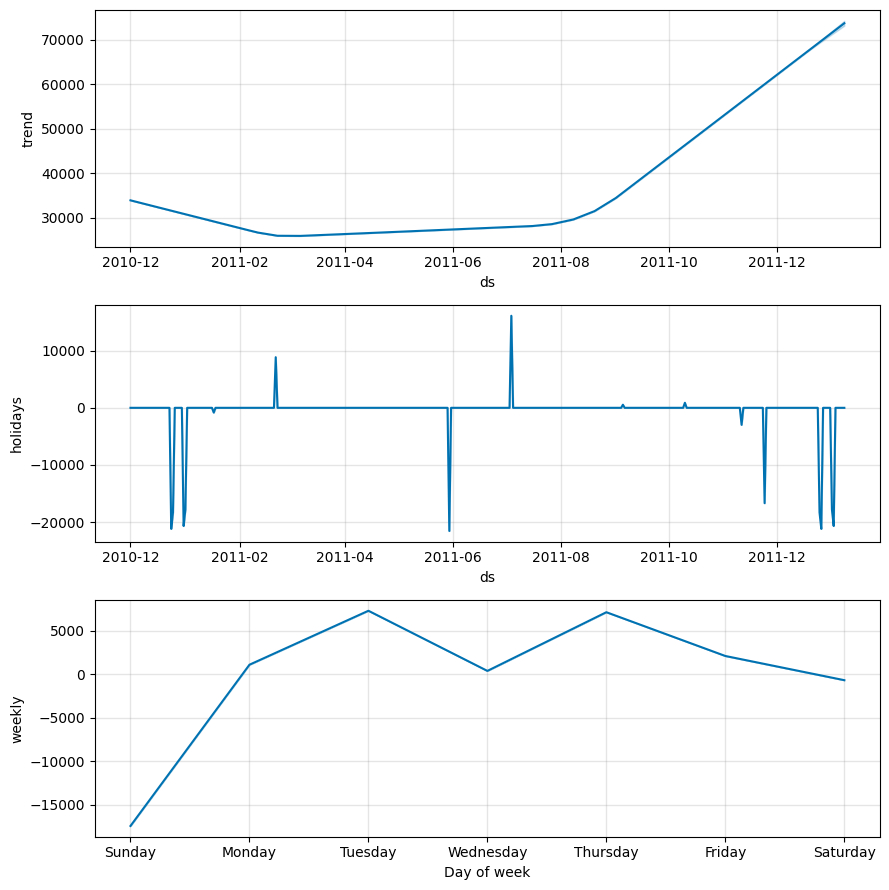

In [6]:
forecast_periods = 30
future = model.make_future_dataframe(periods=forecast_periods)

forecast = model.predict(future)

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
model.plot(forecast, ax=ax)
plt.title('Revenue Forecast using Prophet (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Daily Revenue')
plt.show()

# Plot Components (Trend & Weekly Seasonality)
fig2 = model.plot_components(forecast)
plt.show()